## Five-species leakage sweep
This workbook demonstrates the relationship between global amino acid production rates and effective gLV parameters in a generalised five-species auxotrophy model. The scenario is similar to that presented in __[Mee et al. 2014](https://doi.org/10.1073/pnas.140564111)__, with each population unable to synthesise one essential nutrient but also able to leak a subset of the nutrients required by the other populations.

The results of these analyses are presented in Fig. S6 of the manuscript.

In [1]:
#Import packages used
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
from EOsimsuite import EOsimsuite as EOsim

In [27]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmaxs = EOparams['Vmaxs']
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    sens = Vmaxs[specInd]*monodA*monodG

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmaxs = EOparams['Vmaxs']
    
    sensGrad = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[specInd,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2
    
    sensGrad[-1] = dMonodG*monodA*Vmaxs[specInd]
    sensGrad[specInd] = dMonodA*monodG*Vmaxs[specInd]
    
    return sensGrad

#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmaxs']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    impact = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    for i in range(len(rs)):
        if i == specInd: #If this is the missing amino acid
            impact[i] = -(Vmaxs[specInd]/Ys[specInd,i])*monodG*monodA #Amount of amino acid being used by the strain at this time and converted to biomass
        elif i == len(rs)-1: #If this is the glucose
            impact[i] = -(Vmaxs[specInd]/Ys[specInd,i])*monodG*monodA - sum(Cs[specInd,:-1])*Vmaxs[specInd]*monodG #first term is amount of glucose being converted to biomas, second is amount being converted to amino acids
        else: #If this is any of the (potentially) secreted amino acids
            impact[i] = Cs[specInd,i]*Vmaxs[specInd]*monodG

    return impact

#Gradient of impact function (generates a matrix used in linear stability analysis)
def gradImpactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmaxs = EOparams['Vmaxs']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    nablaF = np.zeros((rs.shape[0],rs.shape[0]))
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[-1,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2

    for i in range(len(rs)):
        if i == specInd: #If the impact is on the missing amino acid
            nablaF[i,i] = -(Vmaxs[specInd]/Ys[i,i])*monodG*dMonodA
            nablaF[i,-1] = -(Vmaxs[specInd]/Ys[i,i])*dMonodG*monodA
        elif i == len(rs)-1: #If the impact is on the glucose
            nablaF[i,specInd] = -(Vmaxs[specInd]/Ys[specInd,i])*monodG*dMonodA
            nablaF[i,-1] = -(Vmaxs[specInd]/Ys[specInd,i])*dMonodG*monodA - sum(Cs[specInd,:-1])*Vmaxs[specInd]*dMonodG
        else: #If the impact is on any of the (potentially) secreted amino acids
            nablaF[i,-1] = Cs[specInd,i]*Vmaxs[specInd]*dMonodG

    return(nablaF)

def instInteract(rs,alphInd,betInd,EOparams):
    return(np.dot(impactFunc(rs,betInd,EOparams),gradSensFunc(rs,alphInd,EOparams)))

def intrinsicGR(rs,alphInd,EOparams,sysParams):
    return(np.dot(gradSensFunc(rs,alphInd,EOparams),sysParams['D']*(sysParams['rIn']-rs)))

In contrast to the two-species auxotrophy model, the parameters that define nutrient production and consumption rates are randomly generated in this model. This function defines the procedure for generating these random quantities.

In [19]:
#Functions that generate random parameter matrices
def genRandMats(noSpec):
    Kvar = 0.5 #Variation of Monod constants
    Yvar = 10 #Variation of yield coefficients
    Vvar = 2 #Variation of maximal growth rates
    Kmu = 1 #Average Monod const.
    Ymu = 20 #Average yield
    Vmu = 10 #Average maximal growth rate
    
    Kms = Kmu + (np.random.rand(noSpec,noSpec+1)-0.5)*Kvar
    Vmaxs = Vmu + (np.random.rand(noSpec)-0.5)*Vvar
    
    Ys = np.zeros((noSpec,noSpec+1))

    Ys[:,-1] = 1
    for i in range(noSpec):
        Ys[i,i] = Ymu + (np.random.rand(1)-0.5)*Kvar

    return [Kms,Ys,Vmaxs]

noSpec = 5

rIn = np.concatenate((np.zeros((noSpec,)),np.array([2.0])),axis=0)
sysParams = {'rIn':rIn}

DilRate = 0.05

In [21]:
np.random.seed(seed=2)
(Kms,Ys,Vmaxs) = genRandMats(noSpec)
CsBase = np.clip(0.15 +(np.random.rand(noSpec,noSpec+1)-0.5)*0.5,a_min=0,a_max=np.inf)
CsBase[:,-1] = 0
for i in range(noSpec):
    CsBase[i,i] = 0

B0 = np.ones((noSpec,))*0.05 #Starting concentration of bacteria in batch (biomass)
maxChemT = 5000

C:\Users\bi1ojm\AppData\Local\Temp\ipykernel_31548\1715874838.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Ys[i,i] = Ymu + (np.random.rand(1)-0.5)*Kvar


These functions define the components of the block matrix representing the true Jacobian for this system (see section 2.3.2 of Supplementary Information). The eigenvalues of this Jacobian give insight into the linear stability properties of this system.

In [23]:
#Write functions that generates the E matrix (the environmental dissipation portion of the Jacobian) as well as the impaact and sensitivity gradient matrices 
def constructEmat(rs,xs,EOparams,D):
    Emat = np.zeros((rs.shape[0],rs.shape[0]))
    Emat -= np.identity(rs.shape[0])*D

    for beta in range(xs.shape[0]):
        Emat += gradImpactFunc(rs,beta,EOparams) * xs[beta]
    return(Emat)

def constructGmat(rs,xs,EOparams):
    Gmat = np.array([gradSensFunc(rs,alpha,EOparams)*xs[alpha] for alpha in range(len(xs))])
    return(Gmat)

def constructFmat(rs,xs,EOparams):
    Fmat = np.array([impactFunc(rs,beta,EOparams) for beta in range(len(xs))])
    return(Fmat.transpose())

def constructJacobian(rs,xs,EOparams,D):
    Emat = constructEmat(rs,xs,EOparams,D)
    Gmat = constructGmat(rs,xs,EOparams)
    Fmat = constructFmat(rs,xs,EOparams)
    Omat = np.zeros((len(xs),len(xs)))

    Jstar = np.block([[Omat,Gmat],[Fmat,Emat]])

    return(Jstar)

Sweep through amino acid production rates. Note that the production rates for all species and all amino acids are raised in tandem (random values multiplied by a universal constant that increases during the sweep). 

In [31]:
noCs = 300
leakStep = 0.001
leakageScales = np.arange(leakStep,noCs*leakStep+leakStep,leakStep)
leakages = leakageScales*np.mean(np.mean(CsBase))

interacts = np.zeros((noSpec,noSpec,noCs))
abunds = np.zeros((noSpec,noCs))
AAlist = np.zeros((noSpec,noCs))

meanInters = np.zeros((noCs,1))
meanIntras = np.zeros((noCs,1))
meanAAs = np.zeros((noCs,1))
eigs = np.zeros((noCs,11))
predAbunds = np.zeros((noCs,5))

for i in range(noCs):
    EOparams = {'Kms':Kms,'Ys':Ys,'Cs':CsBase*leakageScales[i],'Vmaxs':Vmaxs}

    chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
    chemSim.set_timeSettings(tSpan = [0,maxChemT], dt=0.1)
    chemSim.set_dilSettings(D=DilRate,transT=0.1)
    chemSim.set_instInteract(instInteract)
    chemSim.set_intrinsicGR(intrinsicGR)

    chemSim.simEOmodel('Chemostat')

    rStar = chemSim.resTimeseries[:,-1]
    xStar = chemSim.specTimeseries[:,-1]

    abunds[:,i] = xStar

    if sum(xStar>0.0001) == noSpec:    
        intMat = chemSim.assembleIntMat(rStar)
        inter = intMat[~np.eye(intMat.shape[0],dtype=bool)]
        intra = intMat[np.eye(intMat.shape[0],dtype=bool)]

        AAs = chemSim.assembleGRvec(rStar)

        interacts[:,:,i] = intMat
        AAlist[:,i] = AAs
        meanAAs[i] = np.mean(AAs)
        meanInters[i] = np.mean(inter)
        meanIntras[i] = np.mean(intra)

        predAbunds[i,:] = -np.matmul(np.linalg.inv(intMat),AAs)
        
        jac = constructJacobian(rStar,xStar,EOparams,DilRate)
        [eigVals,eigVecs] = np.linalg.eig(jac)
        eigs[i,:] = np.real(eigVals)

Plot the results. We show both the full plot and a zoomed in region of the abiotic/biotic accelerations to show the behaviour of these effective parameters around the onset of coexistence.

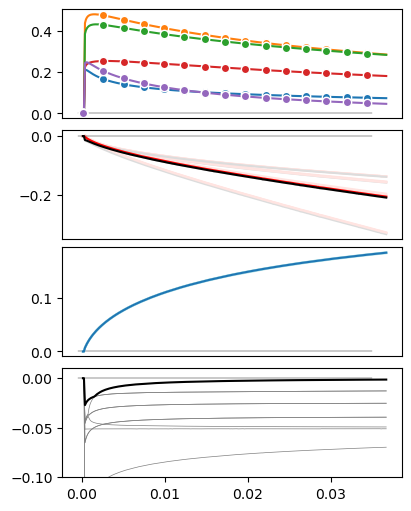

In [41]:
#Display plots of interactions, allogenic accelerations and abundances as function of leakage
fig, axAr = plt.subplots(nrows = 4, ncols = 1, constrained_layout = True, figsize=(4,5))

axAr[0].plot(leakages,abunds.T)

for i in range(noSpec):
    for j in range(noSpec):
        if i == j:
            axAr[1].plot(leakages,interacts[i,j,:],color='gainsboro')
        else:
            axAr[1].plot(leakages,interacts[i,j,:],color='mistyrose')

axAr[0].set_xticks([],[])
axAr[0].plot([-0.0005,0.035],[0,0],'k',linewidth=0.3)

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for i in range(noSpec):
    axAr[0].plot(leakages[::20],predAbunds[::20,i],'o',mfc=colors[i],mec='white')

axAr[1].plot([-0.0005,0.035],[0,0],'k',linewidth=0.3)
axAr[1].plot(leakages,meanInters,'r')
axAr[1].plot(leakages,meanIntras,'k')
axAr[1].set_xticks([],[])

axAr[2].plot([-0.0005,0.035],[0,0],'k',linewidth=0.3)
axAr[2].plot(leakages,AAlist.T,color='powderblue')
axAr[2].plot(leakages,meanAAs)
axAr[2].set_xticks([],[])

eigs.sort(axis=1)
axAr[3].plot([-0.0005,0.035],[0,0],'k',linewidth=0.3)
axAr[3].plot(leakages,eigs,lw=0.5,color='gray')
axAr[3].plot(leakages,np.max(eigs,axis=1),'k')
axAr[3].set_ylim([-0.1,0.01])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\5Spec_AuxotrophProdSweep.pdf")

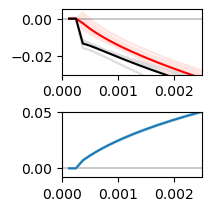

In [142]:
fig, axAr = plt.subplots(nrows = 2, ncols = 1, constrained_layout = True, figsize=(2,2))

for i in range(noSpec):
    for j in range(noSpec):
        if i == j:
            axAr[0].plot(leakages,interacts[i,j,:],color='gainsboro')
        else:
            axAr[0].plot(leakages,interacts[i,j,:],color='mistyrose')
            
axAr[0].plot([-0.0005,0.035],[0,0],'k',linewidth=0.3)
axAr[0].plot(leakages,meanInters,'r')
axAr[0].plot(leakages,meanIntras,'k')

axAr[0].set_xlim([0.000,0.0025])
axAr[0].set_ylim([-0.03,0.005])

axAr[1].plot([-0.0005,0.035],[0,0],'k',linewidth=0.3)
axAr[1].plot(leakages,AAlist.T,color='powderblue')
axAr[1].plot(leakages,meanAAs)
axAr[1].set_xlim([0.000,0.0025])
axAr[1].set_ylim([-0.008,0.05])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophDynamicsZoom.pdf")